VTK Version: 9.4.2
OpenGL2 Enabled: True


Inclination 80: 100%|██████████| 120/120 [00:04<00:00, 26.31it/s]


Simulation completed in 10.41 seconds.
Video saved: /Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/test_discrete_video/test_discrete_inclin=40.mp4
Video saved: /Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/test_discrete_video/test_discrete_inclin=80.mp4


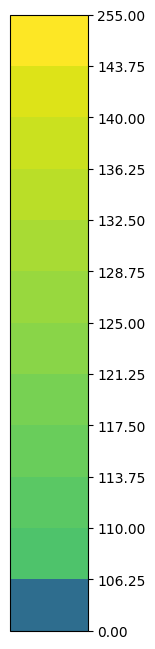

In [ ]:
"""
Created on April 1 2025

Upgrade from AtmosphereGenerator.py:
- significant improvement in speed via vectorization of routines
- gpu acceleration with pyvista but mainly cpu computation
- added multi-pressure capability

@author: nguyendat
"""
# =============================================================================
# IMPORT LIBRARIES
import h5py
import pickle
import os
import json
# =============================================================================
# Enable vtk GPU-backend 
import vtk
# Set debug flags for VTK/OpenGL
os.environ["VTK_DEBUG_OPENGL"] = "1"
os.environ["VTK_REPORT_OPENGL_ERRORS"] = "1"
# =============================================================================
import pyvista as pv
import cv2
from tqdm import tqdm
import numpy as np
# from numba import jit
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import warnings
from scipy.ndimage import gaussian_filter
import pandas as pd
from sklearn.decomposition import PCA
from datetime import datetime
import time
import imageio
from PIL import Image
from sklearn.cluster import KMeans
import gc
# =============================================================================
### Path management
import os
from os.path import join
folderarray = os.path.abspath('').split('/')
homedir = '/'
for i in range(len(folderarray)):
   homedir = join(homedir, folderarray[i])
plotPath = join(homedir, 'plot/')
# ==============================================================================
# Handles spherical mesh generation and geometric calculations
# =============================================================================
class SphericalMesh:
    def __init__(self, resolution=400, radius=1):
        self.radius = radius
        self.resolution = resolution
        self.phi, self.theta = None, None
        self.x, self.y, self.z = None, None, None
        self.generate_mesh()
        
    def generate_mesh(self):
        """Create spherical grid coordinates"""
        phi = np.linspace(0, np.pi, self.resolution)
        # phi = np.arccos(np.linspace(1, -1, self.resolution))  # Cosine spacing
        theta = np.linspace(0, 2*np.pi, self.resolution)
        self.phi, self.theta = np.meshgrid(phi, theta)
        
        self.x = self.radius * np.sin(self.phi) * np.cos(self.theta)
        self.y = self.radius * np.sin(self.phi) * np.sin(self.theta)
        self.z = self.radius * np.cos(self.phi)
    
    @property
    def shape(self):
        return self.x.shape
# ==============================================================================
# Manage config and parameters
# =============================================================================
class TimeConfig:
    """Centralized management of temporal parameters"""
    def __init__(self, t0=0, t1=60, frames=60, option='full'):
        """
        Args:
            t0: Start time (hours)
            t1: End time (hours)
            frames: Number of animation frames
        """
        self.t0 = t0
        self.t1 = t1
        self.frames = frames
        self.option = option
        
        # Derived properties
        if option == 'full':
            self.time_array = np.linspace(t0, t1, frames)
            self.dt = (t1 - t0) / frames  # Time step
        
    def __repr__(self):
        return f"TimeConfig(t0={self.t0}, t1={self.t1}, frames={self.frames}, format={self.option})"

    def _to_dict(self):
        """Convert to JSON-serializable dictionary"""
        return {
            't0': self.t0,
            't1': self.t1,
            'frames': self.frames,
            'dt': self.dt,
            'option': self.option
        }
    
    @classmethod
    def from_dict(cls, d):
        """Reconstruct from dictionary"""
        return cls(t0=d['t0'], t1=d['t1'], frames=d['frames'])
# =============================================================================
class AtmosphericConfig:
    """Combined atmospheric and temporal configuration"""
    def __init__(self, 
                 band_config: list,
                 modu_config: str,
                 modelname: str,
                 time_config: TimeConfig,
                 Fband: float = 1,
                 Fambient: float  = 1,
                 Fpolar: float  = 1,
                 Pband: float  = 5.0,
                 Ppol: float  = 60.0,
                 Fambient_var: float = 0.0,
                 Fpolar_var: float = 0.05,
                 Fband_var: float = 0.05,
                 speckey: dict = None,
                 colorlim: list = [0.5, 1.5]):
        """
        Args:
            band_config: Atmospheric band parameters
            modu_config: Modulation type ('polarStatic' etc)
            modelname: Simulation identifier
            time_config: TimeConfig object
            Fambient/band/pole: Ambient/band/pole base contrast value (amp)
            Fambient_var/band_var/polar_var: Variability value (variab) 
            Pband/pole: Band/pole period (in hours)
            speckey: Spectral value mapping
        """
        self.band_config = band_config
        self.modu_config = modu_config
        self.modelname = modelname
        self.time_config = time_config
        # Base contrast values
        self.Fambient = Fambient
        self.Fband = Fband
        self.Fpolar = Fpolar
        # Variability values
        self.Fband_var = Fband_var
        self.Fpolar_var = Fpolar_var
        self.Fambient_var = Fambient_var
        # Periods in hours
        self.Pband = Pband
        self.Ppol = Ppol
        self.speckey = speckey or {'BG':0, 'A': 150, 'B': 200, 'P': 250}
        self.colorlim = colorlim
        
        self._validate_config()

    def _validate_config(self):
        """Sanity checks for configuration"""
        if not isinstance(self.time_config, TimeConfig):
            raise TypeError("time_config must be TimeConfig instance")
        
        required_band_keys = ['lat2', 'lat1', 'amp', 'typ', 'phase', 'period', 'variab']
        for band in self.band_config:
            if len(band) != len(required_band_keys):
                raise ValueError("Invalid band configuration")

    def _to_dict(self):
        """Convert to JSON-serializable dictionary"""
        return {
            'band_config': self.band_config,
            'modu_config': self.modu_config,
            'modelname': self.modelname,
            'time_config': self.time_config._to_dict(),  # Nested serialization
            'Fambient': self.Fambient,
            'Fband': self.Fband,
            'Fpolar': self.Fpolar,
            'Pband': self.Pband,
            'Ppol': self.Ppol,
            'Fambient_var': self.Fambient_var,
            'Fband_var': self.Fband_var,
            'Fpolar_var': self.Fpolar_var,
            'speckey': self.speckey,
            'colorlim': self.colorlim
        }
    
    @classmethod
    def from_dict(cls, d):
        """Reconstruct from dictionary"""
        time_config = TimeConfig.from_dict(d['time_config'])
        return cls(
            band_config=d['band_config'],
            modu_config=d['modu_config'],
            modelname=d['modelname'],
            time_config=time_config,
            Fambient=d['Fambient'],
            Fband=d['Fband'],
            Fpolar=d['Fpolar'],
            Pband=d['Pband'],
            Ppol=d['Ppol'],
            Fambient_var=d['Fambient_var'],
            Fband_var=d['Fband_var'],
            Fpolar_var=d['Fpolar_var'],
            speckey=d['speckey']
        )
    
    def __repr__(self):
        return f"AtmosphericConfig(model={self.modelname}, time={self.time_config})"

# ==============================================================================
# Core atmospheric simulation logic
# =============================================================================
class AtmosphericModel:
    def __init__(self, mesh, config):
        """
        Args:
            mesh: SphericalMesh object (provides x, y, z coordinates)
            config: AtmosphericConfig object (simulation parameters)
            speckey: Dict mapping region types to spectral values
        """
        self.mesh = mesh
        self.config = config
        self.speckey = config.speckey
        
        # Derived properties from mesh
        self.xsize, self.ysize = self.mesh.shape
        self.xx, self.yy = np.meshgrid(np.arange(self.xsize), np.arange(self.ysize), indexing='ij')
        
        # Precompute latitude grid (vectorized)
        self.lat_grid = np.abs(self.yy - 90) / 180 * self.ysize  # From lat() function

    def generate_specmap(self):
        """
        Generate a spectral mask based on the speckey configuration.
        
        Returns:
            sm: Spectral mask array with shape (xsize, ysize)
        """
        sm = np.full((self.xsize, self.ysize), self.speckey['A'], dtype=np.float32)

        for group in self.config.band_config:
            lat2, lat1, amp, typ, phase, period, variab = group
            lat_px1 = self._lat_px(lat1)
            lat_px2 = self._lat_px(lat2)
            
            # Vectorized latitude mask
            mask = (self.yy >= lat_px2) & (self.yy <= lat_px1)
            sm[mask] = self.speckey[typ.upper()]
        
        return sm

    def generate_atmosphere(self, t, spec=False):
        """
        Generate atmospheric map at time `t`.
        
        Args:
            t: Current timestep
            spec: If True, return spectral map alongside flux map
            
        Returns:
            im (flux map) or (im, sm) tuple if spec=True
        """
        # Initialize base maps
        im = np.full((self.xsize, self.ysize), self.config.Fambient, dtype=np.float32)
        sm = np.full_like(im, self.speckey['A']) if spec else None
        
        # Apply all configured atmospheric features
        for group in self.config.band_config:
            lat2, lat1, amp, typ, phase, period, variab = group
            lat_px1 = self._lat_px(lat1)
            lat_px2 = self._lat_px(lat2)
            wavenumber = self.config.Pband / period
            
            # Vectorized latitude mask
            mask = (self.yy >= lat_px2) & (self.yy <= lat_px1)
            im[mask] = amp
            
            if typ.upper() == 'B':  # Band
                # im = self._apply_discrete_planetary_wave(im, mask, t, amp, phase, period, variab)
                im = self._apply_planetary_wave(im, mask, t, amp, phase, period, variab, wavenumber)

            elif typ.upper() == 'P':  # Polar
                im = self._apply_polar_effect(im, mask, t, amp, phase, period, variab)
                
            if spec:
                sm[mask] = self.speckey[typ.upper()]
                
        # Apply vortices if needed
        if self.config.modu_config in ['polarStatic', 'polarDynamic']:
            im = self._apply_vortices(im, t, self.config.modu_config)
            
        return (im, sm) if spec else im
    
    def _lat_px(self, lat_deg):
        """Convert latitude to pixel coordinate (vectorized)"""
        return np.abs(lat_deg - 90) / 180 * self.ysize
    
    def _apply_planetary_wave(self, im, mask, t, amp, phase, period, variab, wavenumber):
        """Vectorized planetary wave implementation"""
        # Spatial frequency (1/wavelength)
        w = self.xsize / wavenumber  # Full circumference resolution
        sine_wave = variab * np.sin(
            2 * np.pi / w * (self.xx + (t / period) * w) + phase * np.pi / 180
        )
        im[mask] += sine_wave[mask]
        return im
    
    def _apply_polar_effect(self, im, mask, t, amp, phase, period, variab):
        """Polar cap modulation (vectorized)"""
        
        flux = variab * np.sin(2 * np.pi / period * t + phase * np.pi / 180)
        im[mask] += flux
        return im
    
    # [Deprecated] : vectorized vortices implementation
    def _apply_vortices(self, im, t, modu_config):
        """Vectorized vortices implementation"""
        # Get polar regions from config
        polar_groups = [g for g in self.config.band_config if g[3].upper() == 'P']
        
        for group in polar_groups:
            lat2, lat1, *_ = group
            # im = self._circle_vortice_vectorized(im, lat1, lat2, t, group, modu_config)  # Pass full group
            
        return im
    
    def _circle_vortice_vectorized(self, im, lat1, lat2, t, group, modu_config):
        """Vectorized vortex generator (corrected)"""
        # Sort latitudes (lat1 > lat2)
        lat1, lat2 = sorted([lat1, lat2], reverse=True)
        center_lat = (lat1 + lat2) / 2
        center_px = self._lat_px(center_lat)
        lat_px1 = self._lat_px(lat1)
        lat_px2 = self._lat_px(lat2)
        
        # Vortex properties (from config)
        radius_frac = 0.3
        a, b = 0.70, 0.25  # Ellipse axes
        # Make sure area_cap doesn't become negative 
        # when lat1 < lat2 (e.g., southern hemisphere).
        area_cap = 2 * np.pi * abs(np.sin(np.radians(lat1)) - np.sin(np.radians(lat2)))
        r_vortice = np.sqrt(radius_frac * area_cap) * (self.xsize / np.pi)
        ar, br = a * r_vortice, b * r_vortice
        
        # Time-dependent longitudinal positions (corrected drift)
        rotation_period = group[5]
        long_positions = self._equidistant_longitudes(t, rotation_period)

        # Latitude mask
        lat_mask = (self.yy <= lat_px2) & (self.yy >= lat_px1)
        
        # Amplitude from polar region
        amplitude = im[int(self.xsize / 2), self.ysize - 1]  # Central pixel
        
        # Generate grid
        # xx, yy = np.meshgrid(np.arange(self.xsize), np.arange(self.ysize), indexing='ij')
        
        if modu_config == 'polarDynamic':
            phase_values = np.array(2*[0, -2, 5, -4, 8, 2, 4, -6, -8])  # Phase offsets
            variableflux = 0.2 * np.sin(2 * np.pi / rotation_period * t - phase_values[i % len(phase_values)])
        elif modu_config == 'polarStatic':
            phase_values = np.array(2*[0, 0, 0, 0, 0, 0, 0, 0, 0])  # Phase offsets
            variableflux = 0
        amplitude = 0.25*im[int(self.xsize / 2), self.ysize - 1]  # Dynamic amplitude

        # Time-dependent positions (correct drift)
        rotation_period = group[5]
        long_positions = self._equidistant_longitudes(t, rotation_period)
        
        for i, long_px in enumerate(long_positions):
            xi = int(long_px)
            ellipse_mask = (
                ((self.xx - xi) ** 2 / ar ** 2) + 
                ((self.yy - center_px) ** 2 / br ** 2)
            ) <= 1
            
            im[ellipse_mask & lat_mask] += amplitude + variableflux  # Dynamic adjustment
        return im
    
    def _long_px(self, long_deg):
        """Convert longitude (degrees) to pixel coordinate."""
        return (long_deg / 360) * self.xsize  # Match original code's `long()` function

    def _equidistant_longitudes(self, t, rotation_period):
        """Calculate vortex positions with correct degree-to-pixel conversion."""
        n_vortices = 5
        base_pos_deg = np.linspace(0, 360, n_vortices + 1)[:-1]  # Degrees (0-360)
        base_pos = self._long_px(base_pos_deg)  # Convert to pixels
        drift = ((-t % rotation_period) / rotation_period) * self.xsize
        long_positions = (base_pos + drift) % self.xsize  # Overflow

        # Wrap around logic: no empty edges 
        dxCen = np.diff(base_pos)[0]
        if long_positions.min() <= base_pos.min():
            long_positions = np.append(long_positions, long_positions.max() + dxCen)
        if long_positions.max() >= base_pos.max():
            long_positions = np.append(long_positions, long_positions.min() - dxCen)   

        return long_positions

# ==============================================================================
# Visualization of atmospheric data using PyVista
# =============================================================================
class AtmosphereVisualizer:
    def __init__(self, mesh, speckey, config, imsize=(300, 300), inclination=0):
        self.mesh = mesh
        self.inclination = inclination
        self.speckey = speckey
        self.config = config
        self.imsize = imsize
        self.plotter = None

    def configure_plotter(self, zoom_factor=1.01):
        """Configure PyVista plotter with proper camera setup"""
        # Close existing plotter if it exists
        # Force cleanup of previous plotter
        if self.plotter is not None:
            try:
                self.plotter.close()
                del self.plotter
            except:
                pass
            gc.collect()  # Force garbage collection
            
        self.plotter = pv.Plotter(
            off_screen=True,
            window_size=self.imsize,  # Explicit size helps consistency
            lighting='none'  # Remove anisotropy
        )
        
        self.plotter.camera.SetParallelProjection(True)  # Set parallel projection for photometry
        self.plotter.camera.elevation = self.inclination + 56  # Adjust for default value
        self.plotter.background_color = 'black'  # Set background color to black

        # Fine-tune the field of view with parallel_scale
        self.plotter.camera.parallel_scale = zoom_factor  # Uncommented this line
        
        return self.plotter

    # def im_posterize(self, img, tol=15, n_clusters=4, min_count=20):
    #     """Posterize grayscale image using KMeans clustering and remap to speckey values"""
    #     target_values = np.array(list(self.speckey.values()), dtype=np.uint8)

    #     # Flatten to 1D array of intensities
    #     pixels = img.ravel()

    #     # Filter out rare/noisy intensities
    #     unique, counts = np.unique(pixels, return_counts=True)
    #     valid = unique[counts >= min_count]
    #     filtered_pixels = pixels[np.isin(pixels, valid)]

    #     if filtered_pixels.size == 0:
    #         return np.zeros_like(img, dtype=np.uint8), {}

    #     # Run KMeans on filtered values
    #     X = filtered_pixels.reshape(-1, 1)
    #     kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    #     kmeans.fit(X)

    #     # Round centroids to nearest integers and sort them
    #     centroids = np.sort(np.rint(kmeans.cluster_centers_.flatten()).astype(int))

    #     # Map sorted centroids to speckey values (smallest->0, next->80, etc.)
    #     centroid_map = dict(zip(centroids, target_values))

    #     # Create output image initialized to 0
    #     output_img = np.zeros_like(img, dtype=np.uint8)

    #     # Apply mapping: within tolerance of centroid -> mapped speckey value
    #     for c, mapped_val in centroid_map.items():
    #         mask = np.abs(img.astype(int) - int(c)) <= tol
    #         output_img[mask] = mapped_val

    #     return output_img #, centroid_map

    def im_posterize(self, img):
        """Posterize grayscale image by mapping to nearest speckey value"""
        target_values = np.array(sorted(self.speckey.values()), dtype=np.uint8)  # [0, 150, 200, 250]
        
        # For each pixel, find the nearest target value
        img_flat = img.ravel().astype(float)
        
        # Vectorized nearest-neighbor assignment
        distances = np.abs(img_flat[:, np.newaxis] - target_values)
        nearest_indices = np.argmin(distances, axis=1)
        output_img = target_values[nearest_indices]
        
        return np.array(output_img.reshape(img.shape).astype(np.uint8))

    def render_specmask(self, specmap, posterize=True):
        """Render spectral mask with full sphere visible"""
        self.configure_plotter()
        
        # Validate mesh dimensions
        if not hasattr(self.mesh, 'x') or not hasattr(self.mesh, 'y') or not hasattr(self.mesh, 'z'):
            raise AttributeError("Mesh must have x, y, z attributes")
            
        grid = pv.StructuredGrid(self.mesh.x, self.mesh.y, self.mesh.z)
        
        # Validate specmap dimensions
        expected_points = grid.n_points
        if specmap.size != expected_points:
            print(f"Warning: specmap size {specmap.size} doesn't match grid points {expected_points}")
            
        grid.point_data['scalars'] = specmap.ravel(order='F')
        
        # set color limits based on specmap range
        clim = [0,255]

        # Add mesh to plotter
        self.plotter.add_mesh(grid, show_scalar_bar=False, interpolate_before_map=True,
                              cmap='gray', clim=clim)
        self.plotter.camera_set = True  # Lock camera after initial setup

        # Return grayscale screenshot
        screenshot = self.plotter.screenshot()
        if screenshot is None or screenshot.size == 0:
            raise RuntimeError("Screenshot failed - empty or None result")
            
        specmask_clean = screenshot[..., 0]
        
        # Clean up
        self.plotter.close()
        self.plotter = None

        if posterize: 
            return self.im_posterize(specmask_clean)
        else:
            return specmask_clean

    def render_frame(self, atmospheric_data, colorlim=[0.0, 1.0]):
        """Render single timestep with full sphere visible"""
        # Don't reconfigure plotter if it already exists
        if self.plotter is None:
            self.configure_plotter()
            
        grid = pv.StructuredGrid(self.mesh.x, self.mesh.y, self.mesh.z)
        
        # Validate atmospheric_data dimensions
        expected_points = grid.n_points
        if atmospheric_data.size != expected_points:
            print(f"Warning: atmospheric_data size {atmospheric_data.size} doesn't match grid points {expected_points}")
            
        grid.point_data['scalars'] = atmospheric_data.ravel(order='F')

        self.plotter.add_mesh(grid, cmap='gray', show_scalar_bar=False,
                              clim=colorlim, interpolate_before_map=True)
        
        if not hasattr(self.plotter, 'camera_set') or not self.plotter.camera_set:
            self.plotter.camera_set = True  # Lock camera after initial setup
        
        screenshot = self.plotter.screenshot()
        if screenshot is None or screenshot.size == 0:
            raise RuntimeError("Screenshot failed - empty or None result")
            
        grayscale = np.dot(screenshot[..., :3], [0.2989, 0.5870, 0.1140])

        return grayscale

    def digitizer(self, img, bins):
        return None
    
    def photometry(self, config, model, inclin):
        """Generate photometry images over time"""
        colorlim = config.colorlim
        photometry_array = np.empty((config.time_config.frames, 
                                    self.imsize[0], self.imsize[1]), dtype=np.float32)
        time_array = config.time_config.time_array
        self.configure_plotter()

        try:
            for i, t in enumerate(tqdm(time_array, desc=f"Inclination {inclin}")):
                self.plotter.clear()  # Clear previous meshes
                atmospheric_data = model.generate_atmosphere(t)
                frame = self.render_frame(atmospheric_data, colorlim)
                photometry_array[i] = frame
        finally:
            if self.plotter is not None:
                self.plotter.close()
                self.plotter = None

        return photometry_array
    
    def __del__(self):
        """Ensure plotter is closed when object is deleted"""
        if hasattr(self, 'plotter') and self.plotter is not None:
            self.plotter.close()

#=============================================================================
# Multiprocessing helper function: Needs to be placed outside class
# ============================================================================

def process_single_inclination(inclin, config, mesh):
    """Top-level function for multiprocessing"""
    visualizer = AtmosphereVisualizer(mesh=mesh, 
                                      speckey=config.speckey,
                                      config=config,
                                      imsize=[300, 300], 
                                      inclination=inclin)
    model = AtmosphericModel(mesh, config)
    
    gray_array = visualizer.photometry(config, model, inclin)
    specmap = model.generate_specmap()
    specmask = visualizer.render_specmask(specmap, posterize=True)
    
    return {
        'gray_array': gray_array,
        'time_array': config.time_config.time_array,
        'metadata': config._to_dict(),
        'specmask': specmask,
    }
# ==============================================================================
# Run the simulation and visualization
#===============================================================================
class SimulationRunner:
    def __init__(self, config, inclinations, base_path='output'):
        self.mesh = SphericalMesh()
        self.config = config  # Directly use the provided AtmosphericConfig instance
        self.inclinations = inclinations

        # Get current script directory and create full output path
        current_dir = os.path.dirname(os.path.abspath(__file__))
        self.base_path = os.path.join(current_dir, base_path)
        
        # Create directory if it doesn't exist
        os.makedirs(self.base_path, exist_ok=True)

        self.results = {}

    # Running the simulation with multiprocessing
    def run_simulation(self, colorlim=[0.5, 1.5], n_workers=4):
        from multiprocessing import Pool
        start = time.perf_counter()
        
        args_list = [(inclin, self.config, self.mesh) 
                    for inclin in self.inclinations]
        
        with Pool(processes=n_workers) as pool:
            results_list = pool.starmap(process_single_inclination, args_list)
        
        self.results = dict(zip(self.inclinations, results_list))
        
        end = time.perf_counter()
        print(f"Simulation completed in {end - start:.2f} seconds.")
    
        return self.results
        
# ============================================================================
# Input output handler and data management
# ============================================================================
    def save_simulation(self, prefix, compression='gzip'):
        # compression: gzip much smaller filesize than without compression
        results = self.results
        output_path = os.path.join(self.base_path, f'{prefix}.h5')
        with h5py.File(output_path, 'w') as f:
            for inclin, data in results.items():
                f.create_dataset(f'{inclin}/gray_array', 
                                 data=np.array(data['gray_array']), 
                                 chunks=True, compression=compression)
                f.create_dataset(f'{inclin}/specmask', data=data['specmask'])
                f.create_dataset(f'{inclin}/time_array', data=data['time_array'])
                # Save metadata as JSON string
                metadata_json = json.dumps(data['metadata'])
                f.create_dataset(f'{inclin}/metadata', data=metadata_json)
                # f.create_dataset(f'{inclin}/centroids_specmask', data=str(data['centroids_specmask']))

    # ===================================
    # Convert gray_array to video
    # ===================================
    @staticmethod
    def save_video_from_array(gray_array, filepath, fps=30, cmap='plasma', quality='high'):
        """
        Save grayscale array as video with colormap applied.
        
        Parameters:
        -----------
        gray_array : ndarray
            Shape (n_frames, height, width) - grayscale values 0-255
        filepath : str
            Output video path
        fps : int
            Frames per second
        cmap : str
            Matplotlib colormap name (default: 'plasma')
        quality : str
            'high' or 'medium' - affects bitrate
        """
        import matplotlib.pyplot as plt
        
        # Ensure frames are uint8
        if gray_array.dtype != np.uint8:
            frames_uint8 = gray_array.astype(np.uint8)
        else:
            frames_uint8 = gray_array
        
        # Get colormap from matplotlib
        colormap = plt.get_cmap(cmap)
        
        # Apply colormap to each frame
        frames_colored = []
        for frame in frames_uint8:
            # Normalize to 0-1 for colormap
            frame_norm = frame / 255.0
            # Apply colormap (returns RGBA)
            frame_colored = colormap(frame_norm)
            # Convert to RGB (0-255) and drop alpha channel
            frame_rgb = (frame_colored[:, :, :3] * 255).astype(np.uint8)
            # Convert RGB to BGR for OpenCV
            frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
            frames_colored.append(frame_bgr)
        
        height, width, _ = frames_colored[0].shape
        
        # Use H.264 codec for better compression
        fourcc = cv2.VideoWriter_fourcc(*'avc1')  # or try 'H264', 'X264'
        out = cv2.VideoWriter(filepath, fourcc, fps, (width, height))
        
        if not out.isOpened():
            # Fallback to mp4v if H.264 not available
            print("H.264 codec not available, falling back to mp4v")
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(filepath, fourcc, fps, (width, height))
        
        if not out.isOpened():
            raise RuntimeError(f"Failed to open VideoWriter: {filepath}")
        
        for frame in frames_colored:
            out.write(frame)
        
        out.release()
        print(f"Video saved: {filepath}")

    def create_videos_from_h5(self, prefix, fps=30):
        """
        Create grayscale videos for each inclination stored in an HDF5 file.
        """
        h5_file_path = os.path.join(self.base_path, f'{prefix}.h5')
        base_name = os.path.splitext(os.path.basename(h5_file_path))[0]
        output_folder = os.path.join(self.base_path, f"{base_name}_video")
        os.makedirs(output_folder, exist_ok=True)

        with h5py.File(h5_file_path, 'r') as f:
            for inclin in f.keys():
                gray_array = f[f'{inclin}/gray_array'][:]
                video_path = os.path.join(output_folder, f"{base_name}_inclin={inclin}.mp4")
                self.save_video_from_array(gray_array, video_path, fps=fps)

# ==============================================================================
# Light curve generation and plotting
# ==============================================================================
class LightcurveGenerator:
    """
    Compute photometric lightcurves from gray_array and specmask,
    with vectorized flux calculation for efficiency.
    """

    def __init__(self, results: dict):
        self.results = results

    def generate_all(self):
        """Run flux generation for all inclinations in results."""
        for inclination, data in self.results.items():
            self.results[inclination]['flux'] = self._generate_flux(data)

    def _generate_flux(self, data: dict) -> dict:
        """Compute normalized fluxes and area fractions for a single inclination."""
        # Convert gray_array (list of RGB frames) → ndarray (t, h, w, 3), float32
        """Compute normalized fluxes and area fractions for a single inclination."""
        print(f"Debug - type of sum function: {type(sum)}")
        print(f"Debug - sum function: {sum}")
        gray_array = np.array(data['gray_array'], dtype=np.float32)   # shape (t, h, w, 3)
        time_array = np.array(data['time_array'])   # (t,)
        specmask = data['specmask']
        speckey = data['metadata']['speckey']

        # Handle different gray_array formats
        if len(gray_array.shape) == 4:  # (t, h, w, 3) - RGB
            # Convert RGB to grayscale
            gray_array = np.dot(gray_array[..., :3], [0.2989, 0.5870, 0.1140])
        elif len(gray_array.shape) == 3:  # (t, h, w) - already grayscale
            pass
        else:
            raise ValueError(f"Unexpected gray_array shape: {gray_array.shape}")

        frame_height, frame_width = gray_array.shape[1:3]
        norm_const = frame_height * frame_width

        # CRITICAL FIX: Use tolerance-based matching for specmask values
        # The grayscale conversion changes exact spectral values
        indices = {}
        tolerance = 50  # Allow some tolerance for matching
        
        for region, target_value in speckey.items():
            if region == 'BG':
                continue
                
            # Find pixels close to the target spectral value
            mask = np.abs(specmask - target_value) <= tolerance
            idx = np.where(mask)
            
            if len(idx[0]) > 0:
                indices[region] = idx
                print(f"Debug - Found {len(idx[0])} pixels for region '{region}' (target: {target_value})")
            else:
                print(f"Warning: No pixels found for region '{region}' with target value {target_value}")
                # Try finding the closest values
                unique_vals = np.unique(specmask)
                closest_val = unique_vals[np.argmin(np.abs(unique_vals - target_value))]
                print(f"  Closest value in specmask: {closest_val}")

        if not indices:
            print("ERROR: No spectral regions found! This indicates a problem with specmask generation.")
            return {
                'area_fractions': {},
                'time': time_array,
                'fluxtotal': np.zeros(len(time_array))
            }

        # Calculate area fractions
        pixel_counts = {region: len(idx[0]) for region, idx in indices.items()}
        total_area = __builtins__.sum(pixel_counts.values())  # Explicitly convert to list if needed
        total_area = int(total_area)  # Force it to be an integer
        
        if total_area == 0:
            area_fractions = {region: 0.0 for region in indices.keys()}
        else:
            area_fractions = {region: count / total_area for region, count in pixel_counts.items()}

        print(f"Debug - pixel_counts: {pixel_counts}")
        print(f"Debug - pixel_counts.values(): {pixel_counts.values()}")
        print(f"Debug - type of total_area: {type(total_area)}, value: {total_area}")

        # Vectorized flux computation
        fluxes = {}
        for region, idx in indices.items():
            # Extract pixel values across all time steps
            region_pixels = gray_array[:, idx[0], idx[1]]  # Shape: (time, n_pixels)
            flux_region = region_pixels.mean(axis=1)  # Average flux per timestep
            fluxes[f"flux{region}"] = flux_region / norm_const * len(idx[0])  # Scale by region size

        # Total flux
        if fluxes:
            fluxtotal = __builtins__.sum(fluxes.values())
        else:
            fluxtotal = np.zeros(len(time_array))

        print(f"Debug - Generated fluxes for regions: {list(fluxes.keys())}")

        return {
            'area_fractions': area_fractions,
            'time': time_array,
            **fluxes,
            'fluxtotal': fluxtotal
        }

    def plot_all_inclinations(self, flux_type='fluxtotal', normalize=False, 
                                figsize=(10, 6), alpha=0.8):
            """
            Plot lightcurves for all inclinations on the same plot
            Parameters
            ----------
            flux_type : str, optional
                Which flux to plot. Options: 'fluxtotal', 'fluxA', 'fluxB', 'fluxP', etc.
                Default is 'fluxtotal' to show total flux from all regions.
            normalize : bool, optional
                If True, normalize each lightcurve by its own maximum value.
            figsize : tuple, optional
                Figure size (width, height) in inches.
            alpha : float, optional
                Line transparency (0-1).
            """
            import matplotlib.pyplot as plt
            
            # Check if flux data exists
            flux_data_available = {inc: self.results[inc].get('flux', None) 
                                for inc in self.results.keys()}
            
            missing_flux = [inc for inc, data in flux_data_available.items() if data is None]
            if missing_flux:
                raise ValueError(f"No flux data found for inclinations {missing_flux}. "
                                "Run generate_all() first.")

            # Determine available flux types from first inclination
            first_flux_data = list(flux_data_available.values())[0]
            available_flux_types = [k for k in first_flux_data.keys() 
                                if k.startswith('flux') or k == 'fluxtotal']
            
            if flux_type not in available_flux_types:
                raise ValueError(f"Flux type '{flux_type}' not found. "
                                f"Available types: {available_flux_types}")

            plt.figure(figsize=figsize)
            
            # Sort inclinations for consistent color progression
            sorted_inclinations = sorted(self.results.keys())
            
            # Create color gradient based on inclination
            colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(sorted_inclinations)))
            
            # Calculate normalization factor if requested
            normalization_factor = 1.0
            if normalize:
                # Calculate average flux for each inclination (after baseline correction)
                avg_fluxes = []
                for inclination in sorted_inclinations:
                    flux_data = self.results[inclination]['flux']
                    flux = flux_data[flux_type]
                    
                    # Apply baseline correction first (shift to same baseline)
                    flux_corrected = flux - np.min(flux)
                    avg_flux = np.mean(flux_corrected)
                    avg_fluxes.append(avg_flux)
                
                # Use maximum average flux as normalization factor
                if avg_fluxes:
                    normalization_factor = max(avg_fluxes)
                    print(f"Debug - Average fluxes by inclination (baseline-corrected): {dict(zip(sorted_inclinations, avg_fluxes))}")
                    print(f"Debug - Normalization factor (max avg): {normalization_factor}")
            
            for inclination, color in zip(sorted_inclinations, colors):
                flux_data = self.results[inclination]['flux']
                time = flux_data['time']
                flux = flux_data[flux_type]
                
                # Apply baseline correction (shift to same baseline)
                flux_shifted = flux - np.min(flux)
                
                # Normalize by maximum average flux across all inclinations
                if normalize and normalization_factor > 0:
                    flux_final = flux_shifted / normalization_factor
                else:
                    flux_final = flux_shifted
                
                plt.plot(time, flux_final, label=f'{inclination}°', 
                        color=color, alpha=alpha, linewidth=1.5)

            plt.xlabel("Time (hours)")
            ylabel = "Normalized Intensity" if normalize else "Intensity"
            plt.ylabel(ylabel)
            plt.title(f"Lightcurves for All Inclinations: [{flux_type}]")
            
            # Create a nice legend
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                    title='Inclination')
            
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

# ==============================================================================
# Set up configurations and test call
# =============================================================================

if __name__ == "__main__":
    # VTK and OpenGL check
    print("VTK Version:", vtk.vtkVersion.GetVTKVersion())
    print("OpenGL2 Enabled:", hasattr(vtk, 'vtkOpenGLRenderWindow'))

    # Set up band_config: latitudinal features
    Ppol, Pband = 60, 5  # Periods in hours
    Fpolar, Fband, Fambient = 1, 1, 1 # amp
    Fpolar_var, Fband_var, Fambient_var = 0.15, 0.15, 0.00 # variab
    # variability: amp + variab * sin(...)
    ''' 
    bandConfig has to be in this format:
    [latUp, latDown, brightness, type, phase, period, variability] 
    '''

    runName = 'test_discrete'  # Simulation identifier
    bandConfig = [
        [90, 65, Fpolar, 'P', 0, Ppol, Fpolar_var],
        [37, 30., Fband, 'B', 0, Pband/2, Fband_var],
        [15, 5, Fband, 'B', 30, Pband, Fband_var], 
        [-5, -15, Fband, 'B', 0, Pband, Fband_var],
        [-30, -37, Fband, 'B', 30, Pband/2, Fband_var],
        [-65, -90, Fpolar, 'P', 0, Ppol, Fpolar_var]
    ]

    # runName = 'test_discrete2'  # Simulation identifier
    # bandConfig = [
    #     [90, 65, Fpolar, 'P', 0, Ppol, Fpolar_var],
    #     [37, 30., Fband, 'B', 0+120, Pband/2, Fband_var],
    #     [15, 5, Fband, 'B', 30+120, Pband, Fband_var], 
    #     [-5, -15, Fband, 'B', 0+120, Pband, Fband_var],
    #     [-30, -37, Fband, 'B', 30+120, Pband/2, Fband_var],
    #     [-65, -90, Fpolar, 'P', 0, Ppol, Fpolar_var]
    # ]    

    # Set up atmosphere config: the rest of the simulation
    atmo_config = AtmosphericConfig(
        band_config=bandConfig,  # This is your band configuration list
        modu_config='polarStatic',
        modelname='production1',
        time_config=TimeConfig(t0=0, t1=60, frames=120, option='full'),
        Fambient=Fambient,  # This will be accessible as config.Fambient
        Fband=Fband,
        Fpolar=Fpolar,
        Fambient_var=Fambient_var,
        Fband_var=Fband_var,
        Fpolar_var=Fpolar_var,
        speckey= {'BG':0, 'A': 150, 'B': 200, 'P': 250},
        colorlim=[0.0, 2.0] # color_lim sets the mapping range from amplitude to [0.255]
    )

    ### Uncomment for testing: Set up the spherical mesh, initialization
    # mesh = SphericalMesh(resolution=400)
    # model = AtmosphericModel(mesh, atmo_config)
    ## Direct access (works but not ideal)
    # im2d = model._generate_atmosphere(time=30.0)

    incli_array = [40, 80] # List of inclinations to simulate
    # incli_array = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
    # incli_array = [0]
    # Set up the inclination configuration
    runner = SimulationRunner(
        config=atmo_config,
        inclinations=incli_array
    )

    # Run the simulation for a specific time range and number of frames
    results = runner.run_simulation() 

    # Save the simulation results
    runner.save_simulation(runName)

    # Save a video of simulation results
    runner.create_videos_from_h5(runName, fps=6)

#%% Binned image generator and plotter
    def generate_bins(a, b, nbin, type='linear', power=2):
        """
        Generate bins with power-law spacing.
        """
        if type == 'linear':
            bins = np.linspace(a, b, nbin + 1)
        elif type == 'power':
            # Generate interior points only (excluding 0 and 1)
            t = np.linspace(0, 1, nbin)  # Exclude endpoints
            normalized = t ** power
            bins = a + normalized * (b - a)
        return [0] + bins.tolist() + [255]

    # bins = generate_bins(106.25, 143.75, nbin=10, type='power', power=0.9)
    bins = generate_bins(106.25, 143.75, nbin=10, type='linear')

    def plot_frames(h5_path, inclination, t=0, handle='gray', plot_discrete=True, bins=None):
        with h5py.File(h5_path, 'r') as f:
            data = f[f'{inclination}/gray_array'][t]  # Frame at time t
            spec = f[f'{inclination}/specmask']
            fig, axes = plt.subplots(1,3, figsize=(15,5))
            # Original data
            axes[0].imshow(data, vmin=0, vmax=150, cmap='inferno')
            # Binned image
            binned = np.digitize(np.array(data), bins, right=True)
            axes[1].imshow(binned, cmap='viridis')
            # Specmask
            axes[2].imshow(spec, cmap='viridis')
            plt.tight_layout()
            plt.show()
            plt.close()
        return binned

    if False:
        filepath = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'output', runName+'.h5')
        for inc in incli_array:
            for t in range(10):
                binned = plot_frames(filepath, inclination=inc, t=2*t, bins=bins)

    ### Plot horizontal colorbar
    # Normalize bins for colormap

    # Create a colormap
    cmap = cm.viridis
    # Create a normalization based on bins
    norm = colors.Normalize(vmin=0, vmax=150)
    # Create a ScalarMappable for the colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    # Plot colorbar
    fig, ax = plt.subplots(figsize=(1,8))
    cbar = plt.colorbar(sm, cax=ax, orientation='vertical', ticks=bins, boundaries=bins)
    cbar.ax.set_yticklabels([f'{b:.2f}' for b in bins])
    plt.show()

Debug - type of sum function: <class 'numpy._ArrayFunctionDispatcher'>
Debug - sum function: <function sum at 0x1159593a0>
Debug - Found 60354 pixels for region 'A' (target: 150)
Debug - Found 25841 pixels for region 'B' (target: 200)
Debug - Found 29646 pixels for region 'P' (target: 250)
Debug - pixel_counts: {'A': 60354, 'B': 25841, 'P': 29646}
Debug - pixel_counts.values(): dict_values([60354, 25841, 29646])
Debug - type of total_area: <class 'int'>, value: 115841
Debug - Generated fluxes for regions: ['fluxA', 'fluxB', 'fluxP']
Debug - type of sum function: <class 'numpy._ArrayFunctionDispatcher'>
Debug - sum function: <function sum at 0x1159593a0>
Debug - Found 67044 pixels for region 'A' (target: 150)
Debug - Found 24994 pixels for region 'B' (target: 200)
Debug - Found 22956 pixels for region 'P' (target: 250)
Debug - pixel_counts: {'A': 67044, 'B': 24994, 'P': 22956}
Debug - pixel_counts.values(): dict_values([67044, 24994, 22956])
Debug - type of total_area: <class 'int'>, va

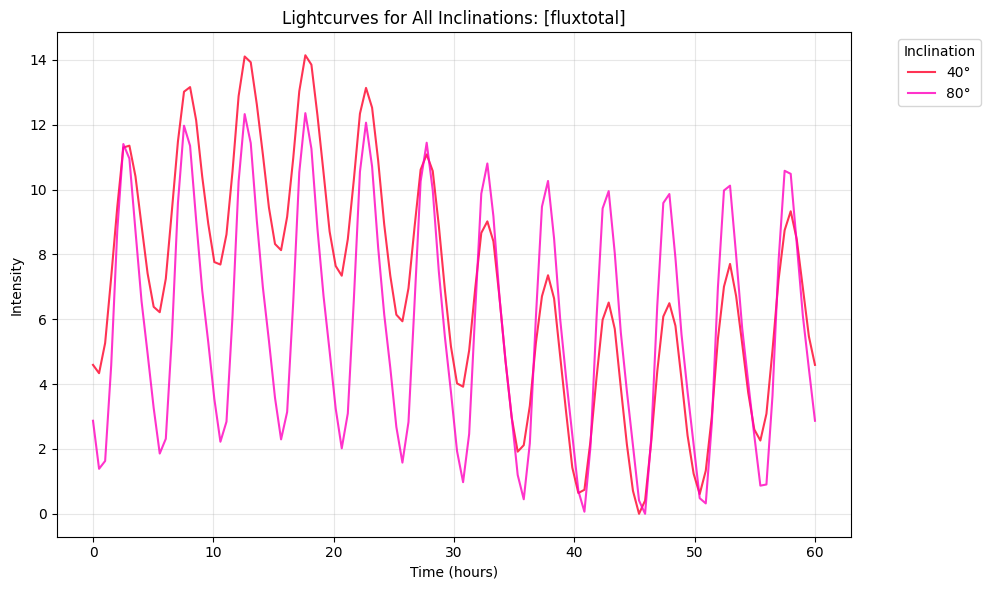

In [ ]:
### After running your simulation
start = time.perf_counter()
lc_generator = LightcurveGenerator(results)
lc_generator.generate_all()
end = time.perf_counter()
print(f"Lightcurve generated in {end - start:.2f} seconds.")

### Plot total flux for all inclinations
lc_generator.plot_all_inclinations()

### Plot regional flux (e.g., bands) for all inclinations  
# lc_generator.plot_all_inclinations(flux_type='fluxA', normalize=False)
# lc_generator.plot_all_inclinations(flux_type='fluxB', normalize=False)
# lc_generator.plot_all_inclinations(flux_type='fluxP', normalize=False)

# Compare flux types for specific inclination
# lc_generator.plot_flux_comparison(inclination=40)

VTK Version: 9.4.2
OpenGL2 Enabled: True


Inclination 40: 100%|██████████| 120/120 [00:05<00:00, 22.51it/s]


Simulation completed in 13.58 seconds.
Video saved: /Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/test_discrete_video/test_discrete_inclin=40.mp4
Video saved: /Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/test_discrete_video/test_discrete_inclin=80.mp4


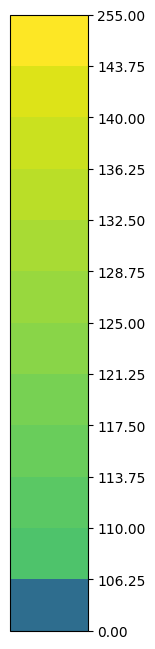

In [ ]:
"""
Created on April 1 2025

Upgrade from AtmosphereGenerator.py:
- significant improvement in speed via vectorization of routines
- gpu acceleration with pyvista but mainly cpu computation
- added multi-pressure capability

@author: nguyendat
"""
# =============================================================================
# IMPORT LIBRARIES
import h5py
import pickle
import os
import json
# =============================================================================
# Enable vtk GPU-backend 
import vtk
# Set debug flags for VTK/OpenGL
os.environ["VTK_DEBUG_OPENGL"] = "1"
os.environ["VTK_REPORT_OPENGL_ERRORS"] = "1"
# =============================================================================
import pyvista as pv
import cv2
from tqdm import tqdm
import numpy as np
# from numba import jit
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import warnings
from scipy.ndimage import gaussian_filter
import pandas as pd
from sklearn.decomposition import PCA
from datetime import datetime
import time
import imageio
from PIL import Image
from sklearn.cluster import KMeans
import gc
# =============================================================================
### Path management
import os
from os.path import join
folderarray = os.path.abspath('').split('/')
homedir = '/'
for i in range(len(folderarray)):
   homedir = join(homedir, folderarray[i])
plotPath = join(homedir, 'plot/')
# ==============================================================================
# Handles spherical mesh generation and geometric calculations
# =============================================================================
class SphericalMesh:
    def __init__(self, resolution=400, radius=1):
        self.radius = radius
        self.resolution = resolution
        self.phi, self.theta = None, None
        self.x, self.y, self.z = None, None, None
        self.generate_mesh()
        
    def generate_mesh(self):
        """Create spherical grid coordinates"""
        phi = np.linspace(0, np.pi, self.resolution)
        # phi = np.arccos(np.linspace(1, -1, self.resolution))  # Cosine spacing
        theta = np.linspace(0, 2*np.pi, self.resolution)
        self.phi, self.theta = np.meshgrid(phi, theta)
        
        self.x = self.radius * np.sin(self.phi) * np.cos(self.theta)
        self.y = self.radius * np.sin(self.phi) * np.sin(self.theta)
        self.z = self.radius * np.cos(self.phi)
    
    @property
    def shape(self):
        return self.x.shape
# ==============================================================================
# Manage config and parameters
# =============================================================================
class TimeConfig:
    """Centralized management of temporal parameters"""
    def __init__(self, t0=0, t1=60, frames=60, option='full'):
        """
        Args:
            t0: Start time (hours)
            t1: End time (hours)
            frames: Number of animation frames
        """
        self.t0 = t0
        self.t1 = t1
        self.frames = frames
        self.option = option
        
        # Derived properties
        if option == 'full':
            self.time_array = np.linspace(t0, t1, frames)
            self.dt = (t1 - t0) / frames  # Time step
        
    def __repr__(self):
        return f"TimeConfig(t0={self.t0}, t1={self.t1}, frames={self.frames}, format={self.option})"

    def _to_dict(self):
        """Convert to JSON-serializable dictionary"""
        return {
            't0': self.t0,
            't1': self.t1,
            'frames': self.frames,
            'dt': self.dt,
            'option': self.option
        }
    
    @classmethod
    def from_dict(cls, d):
        """Reconstruct from dictionary"""
        return cls(t0=d['t0'], t1=d['t1'], frames=d['frames'])
# =============================================================================
class AtmosphericConfig:
    """Combined atmospheric and temporal configuration"""
    def __init__(self, 
                 band_config: list,
                 modu_config: str,
                 modelname: str,
                 time_config: TimeConfig,
                 Fband: float = 1,
                 Fambient: float  = 1,
                 Fpolar: float  = 1,
                 Pband: float  = 5.0,
                 Ppol: float  = 60.0,
                 Fambient_var: float = 0.0,
                 Fpolar_var: float = 0.05,
                 Fband_var: float = 0.05,
                 speckey: dict = None,
                 colorlim: list = [0.5, 1.5]):
        """
        Args:
            band_config: Atmospheric band parameters
            modu_config: Modulation type ('polarStatic' etc)
            modelname: Simulation identifier
            time_config: TimeConfig object
            Fambient/band/pole: Ambient/band/pole base contrast value (amp)
            Fambient_var/band_var/polar_var: Variability value (variab) 
            Pband/pole: Band/pole period (in hours)
            speckey: Spectral value mapping
        """
        self.band_config = band_config
        self.modu_config = modu_config
        self.modelname = modelname
        self.time_config = time_config
        # Base contrast values
        self.Fambient = Fambient
        self.Fband = Fband
        self.Fpolar = Fpolar
        # Variability values
        self.Fband_var = Fband_var
        self.Fpolar_var = Fpolar_var
        self.Fambient_var = Fambient_var
        # Periods in hours
        self.Pband = Pband
        self.Ppol = Ppol
        self.speckey = speckey or {'BG':0, 'A': 150, 'B': 200, 'P': 250}
        self.colorlim = colorlim
        
        self._validate_config()

    def _validate_config(self):
        """Sanity checks for configuration"""
        if not isinstance(self.time_config, TimeConfig):
            raise TypeError("time_config must be TimeConfig instance")
        
        required_band_keys = ['lat2', 'lat1', 'amp', 'typ', 'phase', 'period', 'variab']
        for band in self.band_config:
            if len(band) != len(required_band_keys):
                raise ValueError("Invalid band configuration")

    def _to_dict(self):
        """Convert to JSON-serializable dictionary"""
        return {
            'band_config': self.band_config,
            'modu_config': self.modu_config,
            'modelname': self.modelname,
            'time_config': self.time_config._to_dict(),  # Nested serialization
            'Fambient': self.Fambient,
            'Fband': self.Fband,
            'Fpolar': self.Fpolar,
            'Pband': self.Pband,
            'Ppol': self.Ppol,
            'Fambient_var': self.Fambient_var,
            'Fband_var': self.Fband_var,
            'Fpolar_var': self.Fpolar_var,
            'speckey': self.speckey,
            'colorlim': self.colorlim
        }
    
    @classmethod
    def from_dict(cls, d):
        """Reconstruct from dictionary"""
        time_config = TimeConfig.from_dict(d['time_config'])
        return cls(
            band_config=d['band_config'],
            modu_config=d['modu_config'],
            modelname=d['modelname'],
            time_config=time_config,
            Fambient=d['Fambient'],
            Fband=d['Fband'],
            Fpolar=d['Fpolar'],
            Pband=d['Pband'],
            Ppol=d['Ppol'],
            Fambient_var=d['Fambient_var'],
            Fband_var=d['Fband_var'],
            Fpolar_var=d['Fpolar_var'],
            speckey=d['speckey']
        )
    
    def __repr__(self):
        return f"AtmosphericConfig(model={self.modelname}, time={self.time_config})"

# ==============================================================================
# Core atmospheric simulation logic
# =============================================================================
class AtmosphericModel:
    def __init__(self, mesh, config):
        """
        Args:
            mesh: SphericalMesh object (provides x, y, z coordinates)
            config: AtmosphericConfig object (simulation parameters)
            speckey: Dict mapping region types to spectral values
        """
        self.mesh = mesh
        self.config = config
        self.speckey = config.speckey
        
        # Derived properties from mesh
        self.xsize, self.ysize = self.mesh.shape
        self.xx, self.yy = np.meshgrid(np.arange(self.xsize), np.arange(self.ysize), indexing='ij')
        
        # Precompute latitude grid (vectorized)
        self.lat_grid = np.abs(self.yy - 90) / 180 * self.ysize  # From lat() function

    def generate_specmap(self):
        """
        Generate a spectral mask based on the speckey configuration.
        
        Returns:
            sm: Spectral mask array with shape (xsize, ysize)
        """
        sm = np.full((self.xsize, self.ysize), self.speckey['A'], dtype=np.float32)

        for group in self.config.band_config:
            lat2, lat1, amp, typ, phase, period, variab = group
            lat_px1 = self._lat_px(lat1)
            lat_px2 = self._lat_px(lat2)
            
            # Vectorized latitude mask
            mask = (self.yy >= lat_px2) & (self.yy <= lat_px1)
            sm[mask] = self.speckey[typ.upper()]
        
        return sm

    def generate_atmosphere(self, t, spec=False):
        """
        Generate atmospheric map at time `t`.
        
        Args:
            t: Current timestep
            spec: If True, return spectral map alongside flux map
            
        Returns:
            im (flux map) or (im, sm) tuple if spec=True
        """
        # Initialize base maps
        im = np.full((self.xsize, self.ysize), self.config.Fambient, dtype=np.float32)
        sm = np.full_like(im, self.speckey['A']) if spec else None
        
        # Apply all configured atmospheric features
        for group in self.config.band_config:
            lat2, lat1, amp, typ, phase, period, variab = group
            lat_px1 = self._lat_px(lat1)
            lat_px2 = self._lat_px(lat2)
            wavenumber = self.config.Pband / period
            
            # Vectorized latitude mask
            mask = (self.yy >= lat_px2) & (self.yy <= lat_px1)
            im[mask] = amp
            
            if typ.upper() == 'B':  # Band
                # im = self._apply_discrete_planetary_wave(im, mask, t, amp, phase, period, variab)
                im = self._apply_planetary_wave(im, mask, t, amp, phase, period, variab, wavenumber)

            elif typ.upper() == 'P':  # Polar
                im = self._apply_polar_effect(im, mask, t, amp, phase, period, variab)
                
            if spec:
                sm[mask] = self.speckey[typ.upper()]
                
        # Apply vortices if needed
        if self.config.modu_config in ['polarStatic', 'polarDynamic']:
            im = self._apply_vortices(im, t, self.config.modu_config)
            
        return (im, sm) if spec else im
    
    def _lat_px(self, lat_deg):
        """Convert latitude to pixel coordinate (vectorized)"""
        return np.abs(lat_deg - 90) / 180 * self.ysize
    
    def _apply_planetary_wave(self, im, mask, t, amp, phase, period, variab, wavenumber):
        """Vectorized planetary wave implementation"""
        # Spatial frequency (1/wavelength)
        w = self.xsize / wavenumber  # Full circumference resolution
        sine_wave = variab * np.sin(
            2 * np.pi / w * (self.xx + (t / period) * w) + phase * np.pi / 180
        )
        im[mask] += sine_wave[mask]
        return im
    
    def _apply_polar_effect(self, im, mask, t, amp, phase, period, variab):
        """Polar cap modulation (vectorized)"""
        
        flux = variab * np.sin(2 * np.pi / period * t + phase * np.pi / 180)
        im[mask] += flux
        return im
    
    # [Deprecated] : vectorized vortices implementation
    def _apply_vortices(self, im, t, modu_config):
        """Vectorized vortices implementation"""
        # Get polar regions from config
        polar_groups = [g for g in self.config.band_config if g[3].upper() == 'P']
        
        for group in polar_groups:
            lat2, lat1, *_ = group
            # im = self._circle_vortice_vectorized(im, lat1, lat2, t, group, modu_config)  # Pass full group
            
        return im
    
    def _circle_vortice_vectorized(self, im, lat1, lat2, t, group, modu_config):
        """Vectorized vortex generator (corrected)"""
        # Sort latitudes (lat1 > lat2)
        lat1, lat2 = sorted([lat1, lat2], reverse=True)
        center_lat = (lat1 + lat2) / 2
        center_px = self._lat_px(center_lat)
        lat_px1 = self._lat_px(lat1)
        lat_px2 = self._lat_px(lat2)
        
        # Vortex properties (from config)
        radius_frac = 0.3
        a, b = 0.70, 0.25  # Ellipse axes
        # Make sure area_cap doesn't become negative 
        # when lat1 < lat2 (e.g., southern hemisphere).
        area_cap = 2 * np.pi * abs(np.sin(np.radians(lat1)) - np.sin(np.radians(lat2)))
        r_vortice = np.sqrt(radius_frac * area_cap) * (self.xsize / np.pi)
        ar, br = a * r_vortice, b * r_vortice
        
        # Time-dependent longitudinal positions (corrected drift)
        rotation_period = group[5]
        long_positions = self._equidistant_longitudes(t, rotation_period)

        # Latitude mask
        lat_mask = (self.yy <= lat_px2) & (self.yy >= lat_px1)
        
        # Amplitude from polar region
        amplitude = im[int(self.xsize / 2), self.ysize - 1]  # Central pixel
        
        # Generate grid
        # xx, yy = np.meshgrid(np.arange(self.xsize), np.arange(self.ysize), indexing='ij')
        
        if modu_config == 'polarDynamic':
            phase_values = np.array(2*[0, -2, 5, -4, 8, 2, 4, -6, -8])  # Phase offsets
            variableflux = 0.2 * np.sin(2 * np.pi / rotation_period * t - phase_values[i % len(phase_values)])
        elif modu_config == 'polarStatic':
            phase_values = np.array(2*[0, 0, 0, 0, 0, 0, 0, 0, 0])  # Phase offsets
            variableflux = 0
        amplitude = 0.25*im[int(self.xsize / 2), self.ysize - 1]  # Dynamic amplitude

        # Time-dependent positions (correct drift)
        rotation_period = group[5]
        long_positions = self._equidistant_longitudes(t, rotation_period)
        
        for i, long_px in enumerate(long_positions):
            xi = int(long_px)
            ellipse_mask = (
                ((self.xx - xi) ** 2 / ar ** 2) + 
                ((self.yy - center_px) ** 2 / br ** 2)
            ) <= 1
            
            im[ellipse_mask & lat_mask] += amplitude + variableflux  # Dynamic adjustment
        return im
    
    def _long_px(self, long_deg):
        """Convert longitude (degrees) to pixel coordinate."""
        return (long_deg / 360) * self.xsize  # Match original code's `long()` function

    def _equidistant_longitudes(self, t, rotation_period):
        """Calculate vortex positions with correct degree-to-pixel conversion."""
        n_vortices = 5
        base_pos_deg = np.linspace(0, 360, n_vortices + 1)[:-1]  # Degrees (0-360)
        base_pos = self._long_px(base_pos_deg)  # Convert to pixels
        drift = ((-t % rotation_period) / rotation_period) * self.xsize
        long_positions = (base_pos + drift) % self.xsize  # Overflow

        # Wrap around logic: no empty edges 
        dxCen = np.diff(base_pos)[0]
        if long_positions.min() <= base_pos.min():
            long_positions = np.append(long_positions, long_positions.max() + dxCen)
        if long_positions.max() >= base_pos.max():
            long_positions = np.append(long_positions, long_positions.min() - dxCen)   

        return long_positions

# ==============================================================================
# Visualization of atmospheric data using PyVista
# =============================================================================
class AtmosphereVisualizer:
    def __init__(self, mesh, speckey, config, imsize=(300, 300), inclination=0):
        self.mesh = mesh
        self.inclination = inclination
        self.speckey = speckey
        self.config = config
        self.imsize = imsize
        self.plotter = None

    def configure_plotter(self, zoom_factor=1.01):
        """Configure PyVista plotter with proper camera setup"""
        # Close existing plotter if it exists
        # Force cleanup of previous plotter
        if self.plotter is not None:
            try:
                self.plotter.close()
                del self.plotter
            except:
                pass
            gc.collect()  # Force garbage collection
            
        self.plotter = pv.Plotter(
            off_screen=True,
            window_size=self.imsize,  # Explicit size helps consistency
            lighting='none'  # Remove anisotropy
        )
        
        self.plotter.camera.SetParallelProjection(True)  # Set parallel projection for photometry
        self.plotter.camera.elevation = self.inclination + 56  # Adjust for default value
        self.plotter.background_color = 'black'  # Set background color to black

        # Fine-tune the field of view with parallel_scale
        self.plotter.camera.parallel_scale = zoom_factor  # Uncommented this line
        
        return self.plotter

    # def im_posterize(self, img, tol=15, n_clusters=4, min_count=20):
    #     """Posterize grayscale image using KMeans clustering and remap to speckey values"""
    #     target_values = np.array(list(self.speckey.values()), dtype=np.uint8)

    #     # Flatten to 1D array of intensities
    #     pixels = img.ravel()

    #     # Filter out rare/noisy intensities
    #     unique, counts = np.unique(pixels, return_counts=True)
    #     valid = unique[counts >= min_count]
    #     filtered_pixels = pixels[np.isin(pixels, valid)]

    #     if filtered_pixels.size == 0:
    #         return np.zeros_like(img, dtype=np.uint8), {}

    #     # Run KMeans on filtered values
    #     X = filtered_pixels.reshape(-1, 1)
    #     kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    #     kmeans.fit(X)

    #     # Round centroids to nearest integers and sort them
    #     centroids = np.sort(np.rint(kmeans.cluster_centers_.flatten()).astype(int))

    #     # Map sorted centroids to speckey values (smallest->0, next->80, etc.)
    #     centroid_map = dict(zip(centroids, target_values))

    #     # Create output image initialized to 0
    #     output_img = np.zeros_like(img, dtype=np.uint8)

    #     # Apply mapping: within tolerance of centroid -> mapped speckey value
    #     for c, mapped_val in centroid_map.items():
    #         mask = np.abs(img.astype(int) - int(c)) <= tol
    #         output_img[mask] = mapped_val

    #     return output_img #, centroid_map

    def im_posterize(self, img):
        """Posterize grayscale image by mapping to nearest speckey value"""
        target_values = np.array(sorted(self.speckey.values()), dtype=np.uint8)  # [0, 150, 200, 250]
        
        # For each pixel, find the nearest target value
        img_flat = img.ravel().astype(float)
        
        # Vectorized nearest-neighbor assignment
        distances = np.abs(img_flat[:, np.newaxis] - target_values)
        nearest_indices = np.argmin(distances, axis=1)
        output_img = target_values[nearest_indices]
        
        return np.array(output_img.reshape(img.shape).astype(np.uint8))

    def render_specmask(self, specmap, posterize=True):
        """Render spectral mask with full sphere visible"""
        self.configure_plotter()
        
        # Validate mesh dimensions
        if not hasattr(self.mesh, 'x') or not hasattr(self.mesh, 'y') or not hasattr(self.mesh, 'z'):
            raise AttributeError("Mesh must have x, y, z attributes")
            
        grid = pv.StructuredGrid(self.mesh.x, self.mesh.y, self.mesh.z)
        
        # Validate specmap dimensions
        expected_points = grid.n_points
        if specmap.size != expected_points:
            print(f"Warning: specmap size {specmap.size} doesn't match grid points {expected_points}")
            
        grid.point_data['scalars'] = specmap.ravel(order='F')
        
        # set color limits based on specmap range
        clim = [0,255]

        # Add mesh to plotter
        self.plotter.add_mesh(grid, show_scalar_bar=False, interpolate_before_map=True,
                              cmap='gray', clim=clim)
        self.plotter.camera_set = True  # Lock camera after initial setup

        # Return grayscale screenshot
        screenshot = self.plotter.screenshot()
        if screenshot is None or screenshot.size == 0:
            raise RuntimeError("Screenshot failed - empty or None result")
            
        specmask_clean = screenshot[..., 0]
        
        # Clean up
        self.plotter.close()
        self.plotter = None

        if posterize: 
            return self.im_posterize(specmask_clean)
        else:
            return specmask_clean

    def render_frame(self, atmospheric_data, colorlim=[0.0, 1.0]):
        """Render single timestep with full sphere visible"""
        # Don't reconfigure plotter if it already exists
        if self.plotter is None:
            self.configure_plotter()
            
        grid = pv.StructuredGrid(self.mesh.x, self.mesh.y, self.mesh.z)
        
        # Validate atmospheric_data dimensions
        expected_points = grid.n_points
        if atmospheric_data.size != expected_points:
            print(f"Warning: atmospheric_data size {atmospheric_data.size} doesn't match grid points {expected_points}")
            
        grid.point_data['scalars'] = atmospheric_data.ravel(order='F')

        self.plotter.add_mesh(grid, cmap='gray', show_scalar_bar=False,
                              clim=colorlim, interpolate_before_map=True)
        
        if not hasattr(self.plotter, 'camera_set') or not self.plotter.camera_set:
            self.plotter.camera_set = True  # Lock camera after initial setup
        
        screenshot = self.plotter.screenshot()
        if screenshot is None or screenshot.size == 0:
            raise RuntimeError("Screenshot failed - empty or None result")
            
        grayscale = np.dot(screenshot[..., :3], [0.2989, 0.5870, 0.1140])

        return grayscale

    def digitizer(self, img, bins):
        return None
    
    def photometry(self, config, model, inclin):
        """Generate photometry images over time"""
        colorlim = config.colorlim
        photometry_array = np.empty((config.time_config.frames, 
                                    self.imsize[0], self.imsize[1]), dtype=np.float32)
        time_array = config.time_config.time_array
        self.configure_plotter()

        try:
            for i, t in enumerate(tqdm(time_array, desc=f"Inclination {inclin}")):
                self.plotter.clear()  # Clear previous meshes
                atmospheric_data = model.generate_atmosphere(t)
                frame = self.render_frame(atmospheric_data, colorlim)
                photometry_array[i] = frame
        finally:
            if self.plotter is not None:
                self.plotter.close()
                self.plotter = None

        return photometry_array
    
    def __del__(self):
        """Ensure plotter is closed when object is deleted"""
        if hasattr(self, 'plotter') and self.plotter is not None:
            self.plotter.close()

#=============================================================================
# Multiprocessing helper function: Needs to be placed outside class
# ============================================================================

def process_single_inclination(inclin, config, mesh):
    """Top-level function for multiprocessing"""
    visualizer = AtmosphereVisualizer(mesh=mesh, 
                                      speckey=config.speckey,
                                      config=config,
                                      imsize=[300, 300], 
                                      inclination=inclin)
    model = AtmosphericModel(mesh, config)
    
    gray_array = visualizer.photometry(config, model, inclin)
    specmap = model.generate_specmap()
    specmask = visualizer.render_specmask(specmap, posterize=True)
    
    return {
        'gray_array': gray_array,
        'time_array': config.time_config.time_array,
        'metadata': config._to_dict(),
        'specmask': specmask,
    }
# ==============================================================================
# Run the simulation and visualization
#===============================================================================
class SimulationRunner:
    def __init__(self, config, inclinations, base_path='output'):
        self.mesh = SphericalMesh()
        self.config = config  # Directly use the provided AtmosphericConfig instance
        self.inclinations = inclinations

        # Get current script directory and create full output path
        current_dir = os.path.dirname(os.path.abspath(__file__))
        self.base_path = os.path.join(current_dir, base_path)
        
        # Create directory if it doesn't exist
        os.makedirs(self.base_path, exist_ok=True)

        self.results = {}

    # Running the simulation with multiprocessing
    def run_simulation(self, colorlim=[0.5, 1.5], n_workers=4):
        from multiprocessing import Pool
        start = time.perf_counter()
        
        args_list = [(inclin, self.config, self.mesh) 
                    for inclin in self.inclinations]
        
        with Pool(processes=n_workers) as pool:
            results_list = pool.starmap(process_single_inclination, args_list)
        
        self.results = dict(zip(self.inclinations, results_list))
        
        end = time.perf_counter()
        print(f"Simulation completed in {end - start:.2f} seconds.")
    
        return self.results
        
# ============================================================================
# Input output handler and data management
# ============================================================================
    def save_simulation(self, prefix, compression='gzip'):
        # compression: gzip much smaller filesize than without compression
        results = self.results
        output_path = os.path.join(self.base_path, f'{prefix}.h5')
        with h5py.File(output_path, 'w') as f:
            for inclin, data in results.items():
                f.create_dataset(f'{inclin}/gray_array', 
                                 data=np.array(data['gray_array']), 
                                 chunks=True, compression=compression)
                f.create_dataset(f'{inclin}/specmask', data=data['specmask'])
                f.create_dataset(f'{inclin}/time_array', data=data['time_array'])
                # Save metadata as JSON string
                metadata_json = json.dumps(data['metadata'])
                f.create_dataset(f'{inclin}/metadata', data=metadata_json)
                # f.create_dataset(f'{inclin}/centroids_specmask', data=str(data['centroids_specmask']))

    # ===================================
    # Convert gray_array to video
    # ===================================
    @staticmethod
    def save_video_from_array(gray_array, filepath, fps=30, cmap='inferno', quality='high'):
        """
        Save grayscale array as video with colormap applied.
        
        Parameters:
        -----------
        gray_array : ndarray
            Shape (n_frames, height, width) - grayscale values 0-255
        filepath : str
            Output video path
        fps : int
            Frames per second
        cmap : str
            Matplotlib colormap name (default: 'plasma')
        quality : str
            'high' or 'medium' - affects bitrate
        """
        import matplotlib.pyplot as plt
        
        # Ensure frames are uint8
        if gray_array.dtype != np.uint8:
            frames_uint8 = gray_array.astype(np.uint8)
        else:
            frames_uint8 = gray_array
        
        # Get colormap from matplotlib
        colormap = plt.get_cmap(cmap)
        
        # Apply colormap to each frame
        frames_colored = []
        for frame in frames_uint8:
            # Normalize to 0-1 for colormap
            frame_norm = frame / 255.0
            # Apply colormap (returns RGBA)
            frame_colored = colormap(frame_norm)
            # Convert to RGB (0-255) and drop alpha channel
            frame_rgb = (frame_colored[:, :, :3] * 255).astype(np.uint8)
            # Convert RGB to BGR for OpenCV
            frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
            frames_colored.append(frame_bgr)
        
        height, width, _ = frames_colored[0].shape
        
        # Use H.264 codec for better compression
        fourcc = cv2.VideoWriter_fourcc(*'avc1')  # or try 'H264', 'X264'
        out = cv2.VideoWriter(filepath, fourcc, fps, (width, height))
        
        if not out.isOpened():
            # Fallback to mp4v if H.264 not available
            print("H.264 codec not available, falling back to mp4v")
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(filepath, fourcc, fps, (width, height))
        
        if not out.isOpened():
            raise RuntimeError(f"Failed to open VideoWriter: {filepath}")
        
        for frame in frames_colored:
            out.write(frame)
        
        out.release()
        print(f"Video saved: {filepath}")

    def create_videos_from_h5(self, prefix, fps=30):
        """
        Create grayscale videos for each inclination stored in an HDF5 file.
        """
        h5_file_path = os.path.join(self.base_path, f'{prefix}.h5')
        base_name = os.path.splitext(os.path.basename(h5_file_path))[0]
        output_folder = os.path.join(self.base_path, f"{base_name}_video")
        os.makedirs(output_folder, exist_ok=True)

        with h5py.File(h5_file_path, 'r') as f:
            for inclin in f.keys():
                gray_array = f[f'{inclin}/gray_array'][:]
                video_path = os.path.join(output_folder, f"{base_name}_inclin={inclin}.mp4")
                self.save_video_from_array(gray_array, video_path, fps=fps)

# ==============================================================================
# Light curve generation and plotting
# ==============================================================================
class LightcurveGenerator:
    """
    Compute photometric lightcurves from gray_array and specmask,
    with vectorized flux calculation for efficiency.
    """

    def __init__(self, results: dict):
        self.results = results

    def generate_all(self):
        """Run flux generation for all inclinations in results."""
        for inclination, data in self.results.items():
            self.results[inclination]['flux'] = self._generate_flux(data)

    def _generate_flux(self, data: dict) -> dict:
        """Compute normalized fluxes and area fractions for a single inclination."""
        # Convert gray_array (list of RGB frames) → ndarray (t, h, w, 3), float32
        """Compute normalized fluxes and area fractions for a single inclination."""
        print(f"Debug - type of sum function: {type(sum)}")
        print(f"Debug - sum function: {sum}")
        gray_array = np.array(data['gray_array'], dtype=np.float32)   # shape (t, h, w, 3)
        time_array = np.array(data['time_array'])   # (t,)
        specmask = data['specmask']
        speckey = data['metadata']['speckey']

        # Handle different gray_array formats
        if len(gray_array.shape) == 4:  # (t, h, w, 3) - RGB
            # Convert RGB to grayscale
            gray_array = np.dot(gray_array[..., :3], [0.2989, 0.5870, 0.1140])
        elif len(gray_array.shape) == 3:  # (t, h, w) - already grayscale
            pass
        else:
            raise ValueError(f"Unexpected gray_array shape: {gray_array.shape}")

        frame_height, frame_width = gray_array.shape[1:3]
        norm_const = frame_height * frame_width

        # CRITICAL FIX: Use tolerance-based matching for specmask values
        # The grayscale conversion changes exact spectral values
        indices = {}
        tolerance = 50  # Allow some tolerance for matching
        
        for region, target_value in speckey.items():
            if region == 'BG':
                continue
                
            # Find pixels close to the target spectral value
            mask = np.abs(specmask - target_value) <= tolerance
            idx = np.where(mask)
            
            if len(idx[0]) > 0:
                indices[region] = idx
                print(f"Debug - Found {len(idx[0])} pixels for region '{region}' (target: {target_value})")
            else:
                print(f"Warning: No pixels found for region '{region}' with target value {target_value}")
                # Try finding the closest values
                unique_vals = np.unique(specmask)
                closest_val = unique_vals[np.argmin(np.abs(unique_vals - target_value))]
                print(f"  Closest value in specmask: {closest_val}")

        if not indices:
            print("ERROR: No spectral regions found! This indicates a problem with specmask generation.")
            return {
                'area_fractions': {},
                'time': time_array,
                'fluxtotal': np.zeros(len(time_array))
            }

        # Calculate area fractions
        pixel_counts = {region: len(idx[0]) for region, idx in indices.items()}
        total_area = __builtins__.sum(pixel_counts.values())  # Explicitly convert to list if needed
        total_area = int(total_area)  # Force it to be an integer
        
        if total_area == 0:
            area_fractions = {region: 0.0 for region in indices.keys()}
        else:
            area_fractions = {region: count / total_area for region, count in pixel_counts.items()}

        print(f"Debug - pixel_counts: {pixel_counts}")
        print(f"Debug - pixel_counts.values(): {pixel_counts.values()}")
        print(f"Debug - type of total_area: {type(total_area)}, value: {total_area}")

        # Vectorized flux computation
        fluxes = {}
        for region, idx in indices.items():
            # Extract pixel values across all time steps
            region_pixels = gray_array[:, idx[0], idx[1]]  # Shape: (time, n_pixels)
            flux_region = region_pixels.mean(axis=1)  # Average flux per timestep
            fluxes[f"flux{region}"] = flux_region / norm_const * len(idx[0])  # Scale by region size

        # Total flux
        if fluxes:
            fluxtotal = __builtins__.sum(fluxes.values())
        else:
            fluxtotal = np.zeros(len(time_array))

        print(f"Debug - Generated fluxes for regions: {list(fluxes.keys())}")

        return {
            'area_fractions': area_fractions,
            'time': time_array,
            **fluxes,
            'fluxtotal': fluxtotal
        }

    def plot_all_inclinations(self, flux_type='fluxtotal', normalize=False, 
                                figsize=(10, 6), alpha=0.8):
            """
            Plot lightcurves for all inclinations on the same plot
            Parameters
            ----------
            flux_type : str, optional
                Which flux to plot. Options: 'fluxtotal', 'fluxA', 'fluxB', 'fluxP', etc.
                Default is 'fluxtotal' to show total flux from all regions.
            normalize : bool, optional
                If True, normalize each lightcurve by its own maximum value.
            figsize : tuple, optional
                Figure size (width, height) in inches.
            alpha : float, optional
                Line transparency (0-1).
            """
            import matplotlib.pyplot as plt
            
            # Check if flux data exists
            flux_data_available = {inc: self.results[inc].get('flux', None) 
                                for inc in self.results.keys()}
            
            missing_flux = [inc for inc, data in flux_data_available.items() if data is None]
            if missing_flux:
                raise ValueError(f"No flux data found for inclinations {missing_flux}. "
                                "Run generate_all() first.")

            # Determine available flux types from first inclination
            first_flux_data = list(flux_data_available.values())[0]
            available_flux_types = [k for k in first_flux_data.keys() 
                                if k.startswith('flux') or k == 'fluxtotal']
            
            if flux_type not in available_flux_types:
                raise ValueError(f"Flux type '{flux_type}' not found. "
                                f"Available types: {available_flux_types}")

            plt.figure(figsize=figsize)
            
            # Sort inclinations for consistent color progression
            sorted_inclinations = sorted(self.results.keys())
            
            # Create color gradient based on inclination
            colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(sorted_inclinations)))
            
            # Calculate normalization factor if requested
            normalization_factor = 1.0
            if normalize:
                # Calculate average flux for each inclination (after baseline correction)
                avg_fluxes = []
                for inclination in sorted_inclinations:
                    flux_data = self.results[inclination]['flux']
                    flux = flux_data[flux_type]
                    
                    # Apply baseline correction first (shift to same baseline)
                    flux_corrected = flux - np.min(flux)
                    avg_flux = np.mean(flux_corrected)
                    avg_fluxes.append(avg_flux)
                
                # Use maximum average flux as normalization factor
                if avg_fluxes:
                    normalization_factor = max(avg_fluxes)
                    print(f"Debug - Average fluxes by inclination (baseline-corrected): {dict(zip(sorted_inclinations, avg_fluxes))}")
                    print(f"Debug - Normalization factor (max avg): {normalization_factor}")
            
            for inclination, color in zip(sorted_inclinations, colors):
                flux_data = self.results[inclination]['flux']
                time = flux_data['time']
                flux = flux_data[flux_type]
                
                # Apply baseline correction (shift to same baseline)
                flux_shifted = flux - np.min(flux)
                
                # Normalize by maximum average flux across all inclinations
                if normalize and normalization_factor > 0:
                    flux_final = flux_shifted / normalization_factor
                else:
                    flux_final = flux_shifted
                
                plt.plot(time, flux_final, label=f'{inclination}°', 
                        color=color, alpha=alpha, linewidth=1.5)

            plt.xlabel("Time (hours)")
            ylabel = "Normalized Intensity" if normalize else "Intensity"
            plt.ylabel(ylabel)
            plt.title(f"Lightcurves for All Inclinations: [{flux_type}]")
            
            # Create a nice legend
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                    title='Inclination')
            
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

# ==============================================================================
# Set up configurations and test call
# =============================================================================

if __name__ == "__main__":
    # VTK and OpenGL check
    print("VTK Version:", vtk.vtkVersion.GetVTKVersion())
    print("OpenGL2 Enabled:", hasattr(vtk, 'vtkOpenGLRenderWindow'))

    # Set up band_config: latitudinal features
    Ppol, Pband = 60, 5  # Periods in hours
    Fpolar, Fband, Fambient = 1, 1, 1 # amp
    Fpolar_var, Fband_var, Fambient_var = 0.15, 0.15, 0.00 # variab
    # variability: amp + variab * sin(...)
    ''' 
    bandConfig has to be in this format:
    [latUp, latDown, brightness, type, phase, period, variability] 
    '''

    runName = 'test_discrete'  # Simulation identifier
    bandConfig = [
        [90, 65, Fpolar, 'P', 0, Ppol, Fpolar_var],
        [37, 30., Fband, 'B', 0, Pband/2, Fband_var],
        [15, 5, Fband, 'B', 30, Pband, Fband_var], 
        [-5, -15, Fband, 'B', 0, Pband, Fband_var],
        [-30, -37, Fband, 'B', 30, Pband/2, Fband_var],
        [-65, -90, Fpolar, 'P', 0, Ppol, Fpolar_var]
    ]

    # runName = 'test_discrete2'  # Simulation identifier
    # bandConfig = [
    #     [90, 65, Fpolar, 'P', 0, Ppol, Fpolar_var],
    #     [37, 30., Fband, 'B', 0+120, Pband/2, Fband_var],
    #     [15, 5, Fband, 'B', 30+120, Pband, Fband_var], 
    #     [-5, -15, Fband, 'B', 0+120, Pband, Fband_var],
    #     [-30, -37, Fband, 'B', 30+120, Pband/2, Fband_var],
    #     [-65, -90, Fpolar, 'P', 0, Ppol, Fpolar_var]
    # ]    

    # Set up atmosphere config: the rest of the simulation
    atmo_config = AtmosphericConfig(
        band_config=bandConfig,  # This is your band configuration list
        modu_config='polarStatic',
        modelname='production1',
        time_config=TimeConfig(t0=0, t1=60, frames=120, option='full'),
        Fambient=Fambient,  # This will be accessible as config.Fambient
        Fband=Fband,
        Fpolar=Fpolar,
        Fambient_var=Fambient_var,
        Fband_var=Fband_var,
        Fpolar_var=Fpolar_var,
        speckey= {'BG':0, 'A': 150, 'B': 200, 'P': 250},
        colorlim=[0.0, 2.0] # color_lim sets the mapping range from amplitude to [0.255]
    )

    ### Uncomment for testing: Set up the spherical mesh, initialization
    # mesh = SphericalMesh(resolution=400)
    # model = AtmosphericModel(mesh, atmo_config)
    ## Direct access (works but not ideal)
    # im2d = model._generate_atmosphere(time=30.0)

    incli_array = [40, 80] # List of inclinations to simulate
    # incli_array = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
    # incli_array = [0]
    # Set up the inclination configuration
    runner = SimulationRunner(
        config=atmo_config,
        inclinations=incli_array
    )

    # Run the simulation for a specific time range and number of frames
    results = runner.run_simulation() 

    # Save the simulation results
    runner.save_simulation(runName)

    # Save a video of simulation results
    runner.create_videos_from_h5(runName, fps=6)

#%% Binned image generator and plotter
    def generate_bins(a, b, nbin, type='linear', power=2):
        """
        Generate bins with power-law spacing.
        """
        if type == 'linear':
            bins = np.linspace(a, b, nbin + 1)
        elif type == 'power':
            # Generate interior points only (excluding 0 and 1)
            t = np.linspace(0, 1, nbin)  # Exclude endpoints
            normalized = t ** power
            bins = a + normalized * (b - a)
        return [0] + bins.tolist() + [255]

    # bins = generate_bins(106.25, 143.75, nbin=10, type='power', power=0.9)
    bins = generate_bins(106.25, 143.75, nbin=10, type='linear')

    def plot_frames(h5_path, inclination, t=0, handle='gray', plot_discrete=True, bins=None):
        with h5py.File(h5_path, 'r') as f:
            data = f[f'{inclination}/gray_array'][t]  # Frame at time t
            spec = f[f'{inclination}/specmask']
            fig, axes = plt.subplots(1,3, figsize=(15,5))
            # Original data
            axes[0].imshow(data, vmin=0, vmax=150, cmap='inferno')
            # Binned image
            binned = np.digitize(np.array(data), bins, right=True)
            axes[1].imshow(binned, cmap='viridis')
            # Specmask
            axes[2].imshow(spec, cmap='viridis')
            plt.tight_layout()
            plt.show()
            plt.close()
        return binned

    if False:
        filepath = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'output', runName+'.h5')
        for inc in incli_array:
            for t in range(10):
                binned = plot_frames(filepath, inclination=inc, t=2*t, bins=bins)

    ### Plot horizontal colorbar
    # Normalize bins for colormap

    # Create a colormap
    cmap = cm.viridis
    # Create a normalization based on bins
    norm = colors.Normalize(vmin=0, vmax=150)
    # Create a ScalarMappable for the colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    # Plot colorbar
    fig, ax = plt.subplots(figsize=(1,8))
    cbar = plt.colorbar(sm, cax=ax, orientation='vertical', ticks=bins, boundaries=bins)
    cbar.ax.set_yticklabels([f'{b:.2f}' for b in bins])
    plt.show()

Debug - type of sum function: <class 'numpy._ArrayFunctionDispatcher'>
Debug - sum function: <function sum at 0x1159593a0>
Debug - Found 60354 pixels for region 'A' (target: 150)
Debug - Found 25841 pixels for region 'B' (target: 200)
Debug - Found 29646 pixels for region 'P' (target: 250)
Debug - pixel_counts: {'A': 60354, 'B': 25841, 'P': 29646}
Debug - pixel_counts.values(): dict_values([60354, 25841, 29646])
Debug - type of total_area: <class 'int'>, value: 115841
Debug - Generated fluxes for regions: ['fluxA', 'fluxB', 'fluxP']
Debug - type of sum function: <class 'numpy._ArrayFunctionDispatcher'>
Debug - sum function: <function sum at 0x1159593a0>
Debug - Found 67044 pixels for region 'A' (target: 150)
Debug - Found 24994 pixels for region 'B' (target: 200)
Debug - Found 22956 pixels for region 'P' (target: 250)
Debug - pixel_counts: {'A': 67044, 'B': 24994, 'P': 22956}
Debug - pixel_counts.values(): dict_values([67044, 24994, 22956])
Debug - type of total_area: <class 'int'>, va

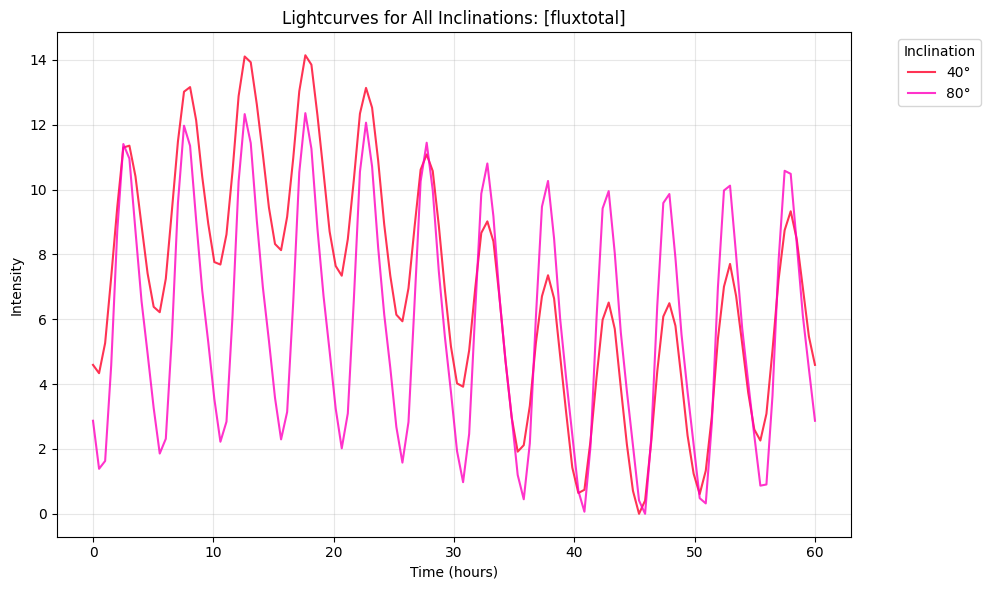

In [ ]:
### After running your simulation
start = time.perf_counter()
lc_generator = LightcurveGenerator(results)
lc_generator.generate_all()
end = time.perf_counter()
print(f"Lightcurve generated in {end - start:.2f} seconds.")

### Plot total flux for all inclinations
lc_generator.plot_all_inclinations()

### Plot regional flux (e.g., bands) for all inclinations  
# lc_generator.plot_all_inclinations(flux_type='fluxA', normalize=False)
# lc_generator.plot_all_inclinations(flux_type='fluxB', normalize=False)
# lc_generator.plot_all_inclinations(flux_type='fluxP', normalize=False)

# Compare flux types for specific inclination
# lc_generator.plot_flux_comparison(inclination=40)